In [3]:
trade_path = r"C:\Users\AJ\Desktop\Dev Work\Bt_WorkFlow\Results\trades.csv"

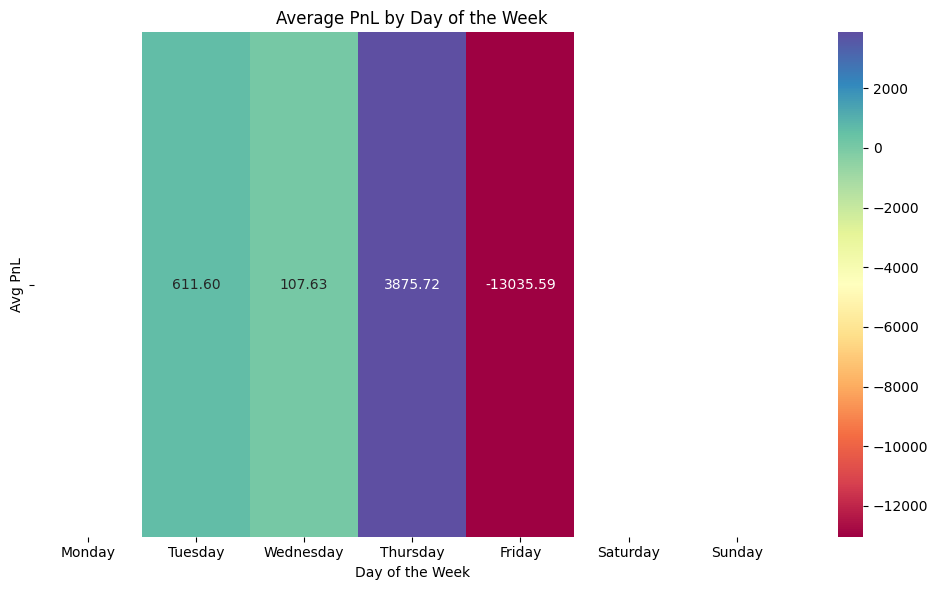


===== Performance by Day of the Week =====
           TotalTrades  TotalPnL%   AvgPnL%
DayOfWeek                                  
Monday               0        NaN       NaN
Tuesday             60  18.085715  0.301429
Wednesday           58   3.076507  0.053043
Thursday            48  91.686943  1.910145
Friday               2 -12.849164 -6.424582
Saturday             0        NaN       NaN
Sunday               0        NaN       NaN


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Load the CSV file
df = pd.read_csv(trade_path, parse_dates=["EntryTime", "ExitTime"])

# Extract the day of the week (DOW) from the EntryTime
df['DayOfWeek'] = df['EntryTime'].dt.day_name()

# Group by Day of the Week and calculate performance metrics
dow_performance = df.groupby('DayOfWeek').agg(
    TotalTrades=('PnL', 'count'),
    TotalPnL=('PnL', 'sum'),
    AvgPnL=('PnL', 'mean')
).reindex(list(calendar.day_name))  # Convert calendar.day_name to a list

# Calculate percentage metrics
total_pnl_sum = dow_performance['TotalPnL'].sum()
dow_performance['TotalPnL%'] = (dow_performance['TotalPnL'] / abs(total_pnl_sum)) * 100  # Use absolute value of total PnL
dow_performance['AvgPnL%'] = (dow_performance['AvgPnL'] / abs(total_pnl_sum)) * 100  # Use absolute value of total PnL

# Fill NaN values in TotalTrades with 0 and convert to integers
dow_performance['TotalTrades'] = dow_performance['TotalTrades'].fillna(0).astype(int)

# --- Visualization: Calendar-like Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(
    dow_performance[['AvgPnL']].T,  # Transpose to show DOW as columns
    annot=True, fmt=".2f", cmap="Spectral", cbar=True,
    xticklabels=dow_performance.index, yticklabels=["Avg PnL"]
)
plt.title("Average PnL by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("")
plt.tight_layout()
plt.show()

# --- Print Summary ---
print("\n===== Performance by Day of the Week =====")
print(dow_performance[['TotalTrades', 'TotalPnL%', 'AvgPnL%']])

In [5]:
# Ensure 'HourOfDay' column is created
df['HourOfDay'] = df['EntryTime'].dt.hour

# Calculate performance metrics by Hour of the Day
hourly_performance = df.groupby('HourOfDay').agg(
    TotalTrades=('PnL', 'count'),
    TotalPnL=('PnL', 'sum'),
    AvgPnL=('PnL', 'mean')
)

# Calculate percentage metrics for hourly performance
total_hourly_pnl_sum = hourly_performance['TotalPnL'].sum()
hourly_performance['TotalPnL%'] = (hourly_performance['TotalPnL'] / abs(total_hourly_pnl_sum)) * 100  # Use absolute value of total PnL
hourly_performance['AvgPnL%'] = (hourly_performance['AvgPnL'] / abs(total_hourly_pnl_sum)) * 100  # Use absolute value of total PnL

# Fill NaN values in TotalTrades with 0 and convert to integers
hourly_performance['TotalTrades'] = hourly_performance['TotalTrades'].fillna(0).astype(int)

# Print the hourly performance stats
print("\n===== Performance by Hour of the Day =====")
print(hourly_performance[['TotalTrades', 'TotalPnL%', 'AvgPnL%']])


===== Performance by Hour of the Day =====
           TotalTrades  TotalPnL%   AvgPnL%
HourOfDay                                  
0                    7 -16.384809 -2.340687
1                    4   0.702069  0.175517
2                   14  22.184687  1.584621
3                    5   2.178167  0.435633
4                   11  42.825915  3.893265
5                    7   2.982571  0.426082
6                   11 -15.901407 -1.445582
7                   12  13.256598  1.104717
8                    5 -20.696517 -4.139303
9                    4  22.232361  5.558090
10                   3   9.036600  3.012200
11                   6   7.872425  1.312071
12                  10 -15.954216 -1.595422
13                   7   6.979216  0.997031
14                   9  10.096842  1.121871
15                   9  22.071189  2.452354
16                   4  -6.016873 -1.504218
17                   8 -10.622523 -1.327815
18                   5  -5.917199 -1.183440
19                  10   2.44498

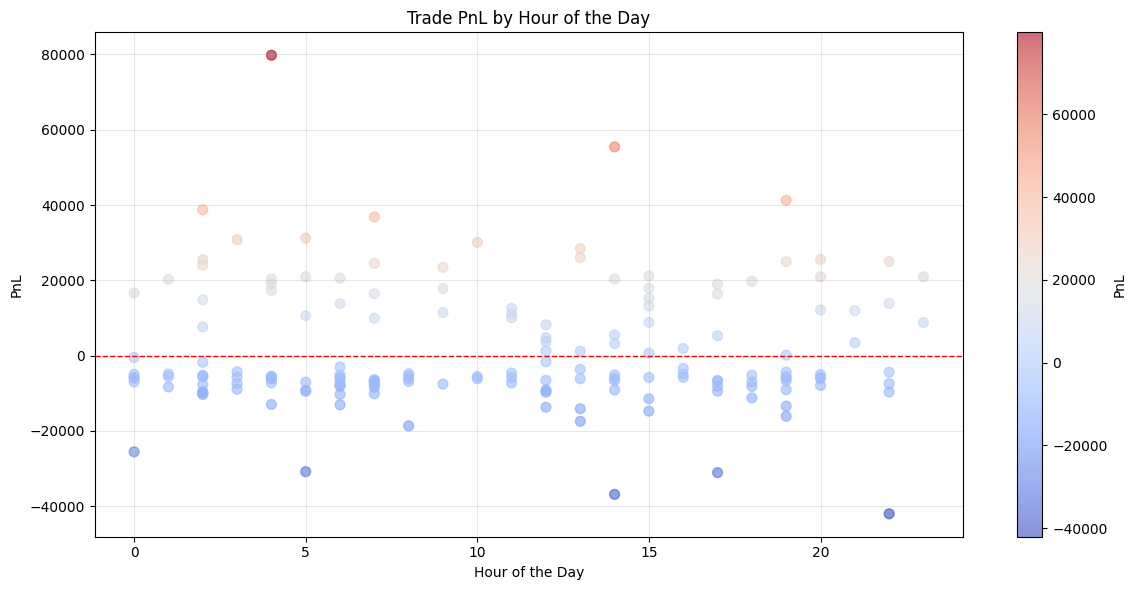

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Load the CSV file
df = pd.read_csv(trade_path, parse_dates=["EntryTime", "ExitTime"])

# Extract the day of the week (DOW) and hour of the day from the EntryTime
df['DayOfWeek'] = df['EntryTime'].dt.day_name()
df['HourOfDay'] = df['EntryTime'].dt.hour

# --- Scatter Plot for Hourly Performance ---
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df['HourOfDay'], df['PnL'], 
    alpha=0.6, c=df['PnL'], cmap='coolwarm', s=50
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # Add a horizontal line at 0 for reference
plt.colorbar(scatter, label="PnL")  # Add a color bar to show PnL values
plt.title("Trade PnL by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("PnL")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

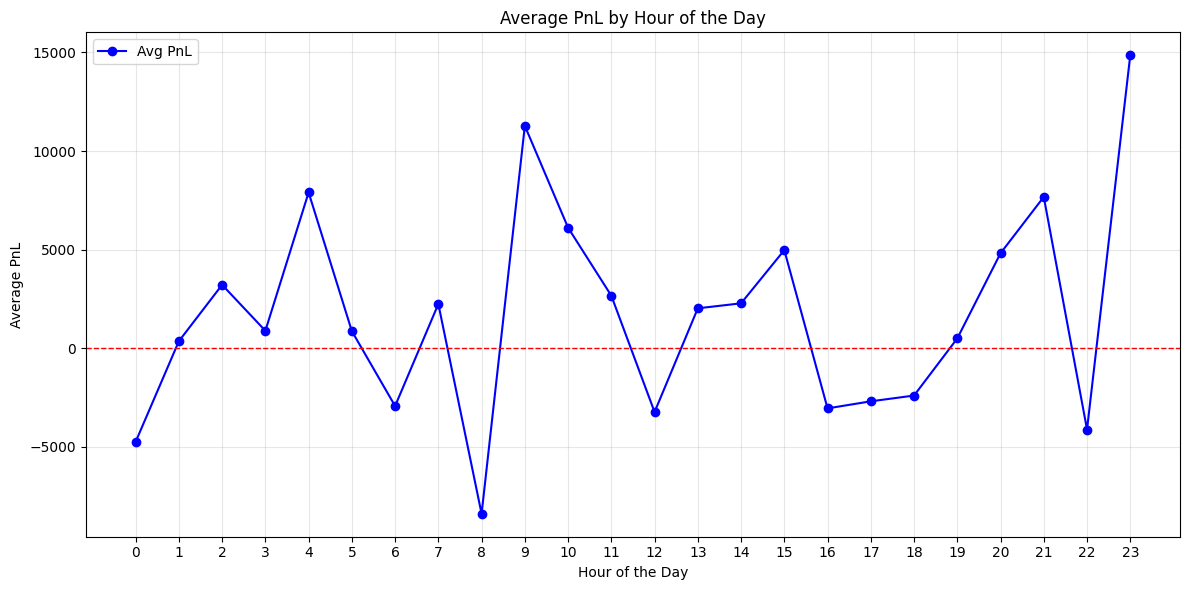

In [7]:
# Line Chart for Hourly Performance
plt.figure(figsize=(12, 6))
plt.plot(hourly_performance.index, hourly_performance['AvgPnL'], marker='o', label='Avg PnL', color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # Add a horizontal line at 0 for reference
plt.title("Average PnL by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average PnL")
plt.xticks(hourly_performance.index)  # Ensure all hours are shown on the x-axis
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

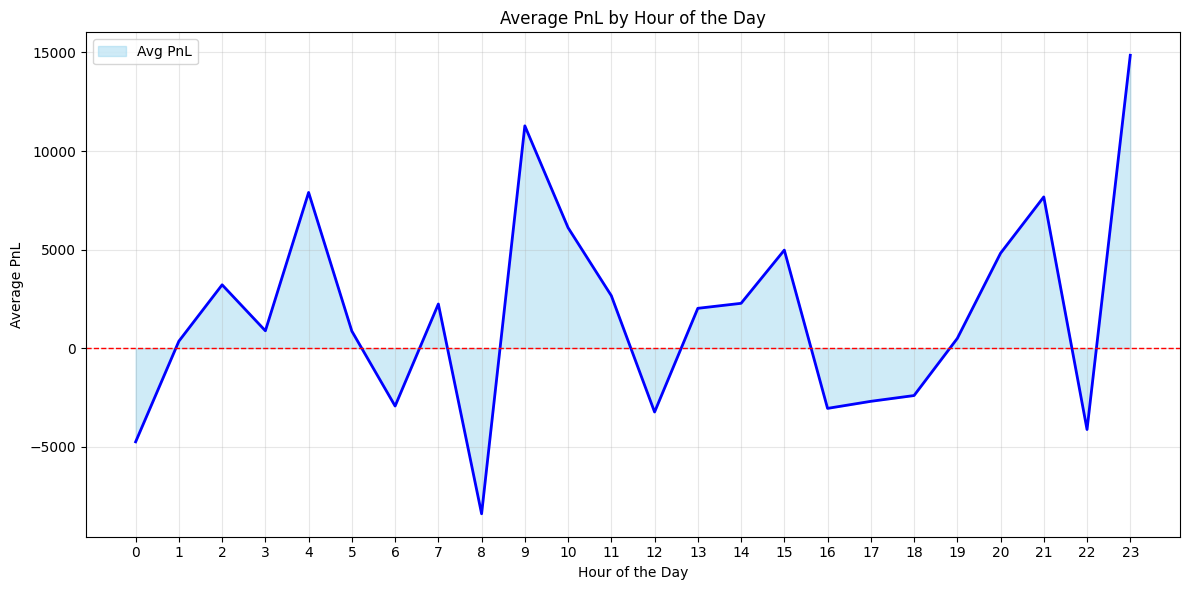

In [8]:
# Area Chart for Hourly Performance
plt.figure(figsize=(12, 6))
plt.fill_between(hourly_performance.index, hourly_performance['AvgPnL'], color='skyblue', alpha=0.4, label='Avg PnL')
plt.plot(hourly_performance.index, hourly_performance['AvgPnL'], color='blue', linewidth=2)
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # Add a horizontal line at 0 for reference
plt.title("Average PnL by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average PnL")
plt.xticks(hourly_performance.index)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()